In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('crop_yield.csv.zip')

# Filter one state and crop
df = df[(df['State'] == 'Punjab') & (df['Crop'] == 'Rice')]

df = df.sort_values('Crop_Year')
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
6297,Rice,1997,Kharif,Punjab,2281000.0,7904000,690.1,217082770.0,707110.0,3.476471
6553,Rice,1998,Kharif,Punjab,2519000.0,7940000,588.6,248877200.0,730510.0,3.099412
6961,Rice,1999,Kharif,Punjab,2604000.0,8716000,364.4,276362520.0,703080.0,3.332353
7357,Rice,2000,Kharif,Punjab,2611000.0,9154000,405.3,256321870.0,678860.0,3.501765
7800,Rice,2001,Kharif,Punjab,2487000.0,8816000,479.3,253997310.0,646620.0,3.517059


In [ ]:
df['Crop_Year'] = pd.to_datetime(df['Crop_Year'], format='%Y')
df.set_index('Crop_Year', inplace=True)

yield_ts = df['Yield']
yield_ts

,Yield
Crop_Year,
1997-01-01,3.476471
1998-01-01,3.099412
1999-01-01,3.332353
2000-01-01,3.501765
2001-01-01,3.517059
2002-01-01,3.438824
2003-01-01,3.678235
2004-01-01,3.788824
2005-01-01,3.820588


 🧠Milestone 1: Data Acquisition

 Data acquisition involves collecting reliable historical crop yield data from official agricultural sources. In this study, state-wise and year-wise crop yield data was obtained from government databases, along with relevant weather data such as rainfall. These datasets were integrated using common attributes like year and state to create a consistent time series suitable for analysis and model development.

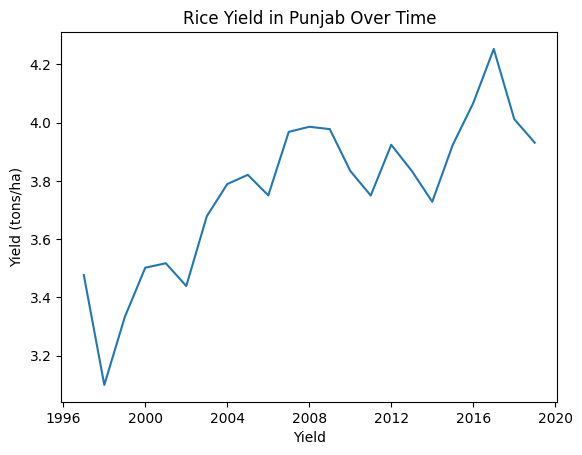

In [ ]:
plt.figure()
plt.plot(yield_ts)
plt.title('Rice Yield in Punjab Over Time')
plt.xlabel('Yield')
plt.ylabel('Yield (tons/ha)')
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(yield_ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -3.7669591265940006
p-value: 0.003264045394314801


In [ ]:
yield_diff = yield_ts.diff().dropna()

adfuller(yield_diff)[1]


np.float64(0.9065821212787846)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(yield_ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Yield   No. Observations:                   23
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   9.129
Date:                Tue, 30 Dec 2025   AIC                            -12.257
Time:                        10:46:43   BIC                             -8.984
Sample:                    01-01-1997   HQIC                           -11.486
                         - 01-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4422      0.843      0.524      0.600      -1.210       2.095
ma.L1         -0.6447      0.751     -0.858      0.391      -2.117       0.828
sigma2         0.0254      0.010      2.634      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast = model_fit.forecast(steps=5)
forecast


,predicted_mean
2020-01-01,3.951333
2021-01-01,3.960364
2022-01-01,3.964358
2023-01-01,3.966124
2024-01-01,3.966905


🧠USES OF EDA(Exploratory Data Analysis)

“Boxplots were used to identify outliers and variability in crop yield across states. Heatmaps revealed strong correlations between yield and rainfall. Scatter plots showed a positive relationship between rainfall and yield, while line plots captured temporal yield trends. These visualizations guided feature selection and model choice.”

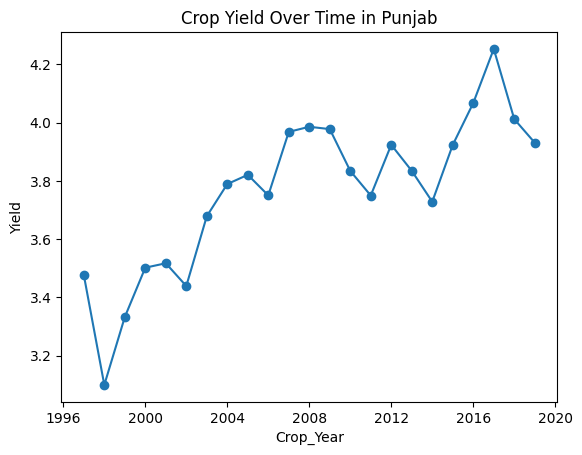

In [ ]:
state_df = df[df['State'] == 'Punjab']

plt.figure()
plt.plot(state_df.index, state_df['Yield'], marker='o')
plt.title('Crop Yield Over Time in Punjab')
plt.xlabel('Crop_Year')
plt.ylabel('Yield')
plt.show()

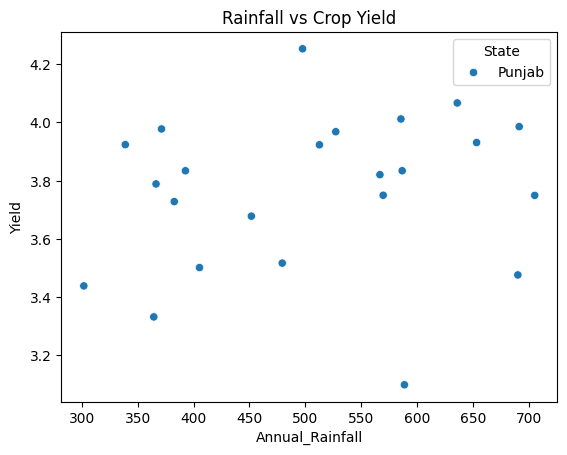

In [ ]:
import seaborn as sns
plt.figure()
sns.scatterplot(x='Annual_Rainfall', y='Yield', hue='State', data=df)
plt.title('Rainfall vs Crop Yield')
plt.show()

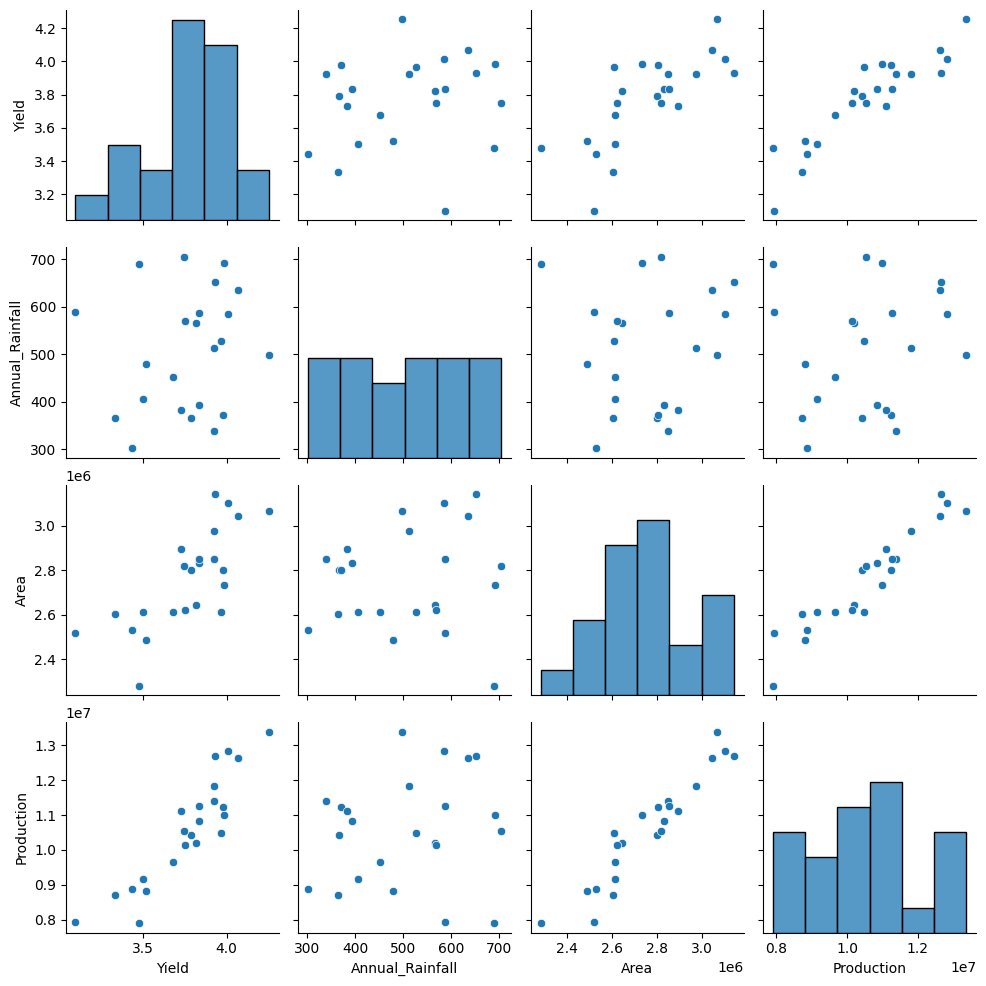

In [ ]:
sns.pairplot(df[['Yield', 'Annual_Rainfall', 'Area', 'Production']])
plt.show()

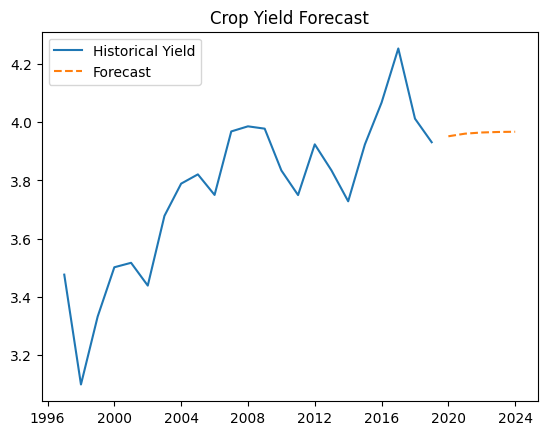

In [ ]:
plt.figure()
plt.plot(yield_ts, label='Historical Yield')
plt.plot(forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title('Crop Yield Forecast')
plt.show()


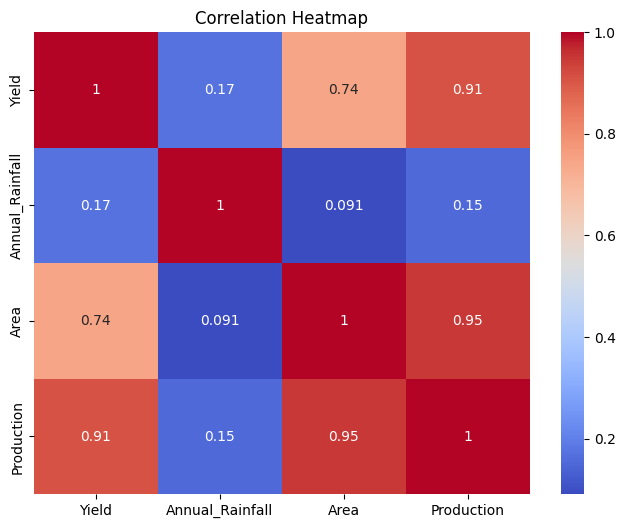

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['Yield', 'Annual_Rainfall', 'Area', 'Production']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

🧠Milestone 2: Model Development and Training

The model’s performance is evaluated using error metrics such as Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE) by comparing predicted yield values with actual observed values.The model development phase focuses on selecting an appropriate algorithm to capture patterns in historical crop yield data

In [ ]:
train = yield_ts[:-5]
test = yield_ts[-5:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

predictions = model_fit.forecast(steps=5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


<Figure size 640x480 with 0 Axes>

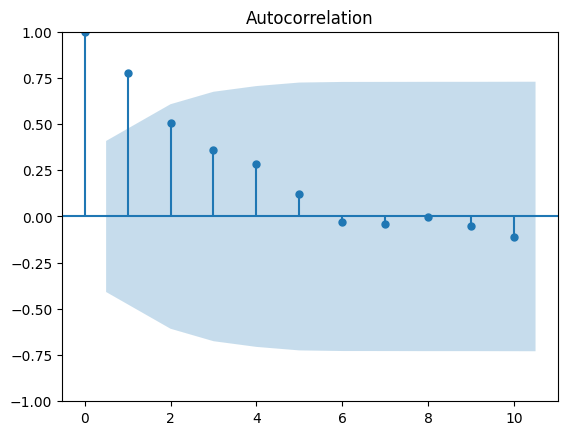

<Figure size 640x480 with 0 Axes>

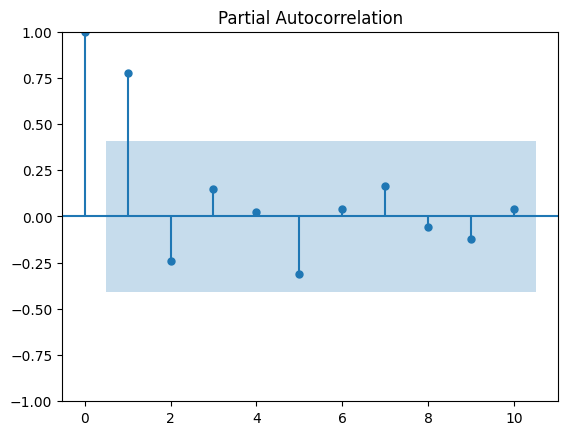

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure()
plot_acf(yield_ts, lags=10)
plt.show()

plt.figure()
plot_pacf(yield_ts, lags=10)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(yield_ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.7669591265940006
p-value: 0.003264045394314801


If p-value > 0.05

In [ ]:
ts_diff = yield_ts.diff().dropna()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Example (p=1, d=1, q=1)
model_arima = ARIMA(yield_ts, order=(1,1,1))
arima_fit = model_arima.fit()

print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Yield   No. Observations:                   23
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   9.129
Date:                Tue, 30 Dec 2025   AIC                            -12.257
Time:                        10:48:26   BIC                             -8.984
Sample:                    01-01-1997   HQIC                           -11.486
                         - 01-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4422      0.843      0.524      0.600      -1.210       2.095
ma.L1         -0.6447      0.751     -0.858      0.391      -2.117       0.828
sigma2         0.0254      0.010      2.634      0.0

In [ ]:
forecast_arima = arima_fit.forecast(steps=5)
forecast_arima


,predicted_mean
2020-01-01,3.951333
2021-01-01,3.960364
2022-01-01,3.964358
2023-01-01,3.966124
2024-01-01,3.966905


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    yield_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)  # 12 = yearly seasonality
)

sarima_fit = model_sarima.fit()
print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Yield   No. Observations:                   23
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   3.409
Date:                            Tue, 30 Dec 2025   AIC                              3.181
Time:                                    10:48:52   BIC                              4.694
Sample:                                01-01-1997   HQIC                             1.522
                                     - 01-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2425      2.273      0.107      0.915      -4.213       4.698
ma.L1         -0.5157      2.435   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_forecast = sarima_fit.forecast(steps=5)
sarima_forecast


,predicted_mean
2020-01-01,4.040481
2021-01-01,4.043597
2022-01-01,4.113131
2023-01-01,3.740657
2024-01-01,3.919140


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(yield_ts).fit()
ses_forecast = ses_model.forecast(5)
ses_forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,0
2020-01-01,3.954755
2021-01-01,3.954755
2022-01-01,3.954755
2023-01-01,3.954755
2024-01-01,3.954755


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae_ses = mean_absolute_error(test, ses_forecast)
rmse_ses = np.sqrt(mean_squared_error(test, ses_forecast))

print("SES MAE:", mae_ses)
print("SES RMSE:", rmse_ses)


SES MAE: 0.10450356791198283
SES RMSE: 0.14571713971135364


In [ ]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(yield_ts).fit()
holt_forecast = holt_model.forecast(5)
holt_forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,0
2020-01-01,3.881186
2021-01-01,3.815030
2022-01-01,3.748874
2023-01-01,3.682718
2024-01-01,3.616562


In [ ]:
mae_holt = mean_absolute_error(test, holt_forecast)
rmse_holt = np.sqrt(mean_squared_error(test, holt_forecast))

print("Holt MAE:", mae_holt)
print("Holt RMSE:", rmse_holt)


Holt MAE: 0.2882170090492558
Holt RMSE: 0.32439184647885283


In [ ]:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 30.3 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

auto_model = auto_arima(
    yield_ts,
    seasonal=True,
    m=12,
    trace=True
)

print(auto_model.summary())


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/utils.py:117: UserWarning: Appropriate D value may not have been reached; length of seasonally-differenced array (11) is shorter than m (12). Using D=1
  warnings.warn("Appropriate D value may not have been reached; "


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=139192.851, Time=1.01 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-2.225, Time=0.10 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=inf, Time=3.38 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-0.724, Time=0.64 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=12.811, Time=0.04 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=-0.225, Time=0.47 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-0.225, Time=1.64 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1.775, Time=1.38 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-2.517, Time=0.21 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=2.22 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=2.55 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=-0.744, Time=0.26 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-0.765, Time=0.39 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=-2.724, Time=0.61 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=-0.724, Ti

In [ ]:

mae = mean_absolute_error(test, forecast_arima)
rmse = np.sqrt(mean_squared_error(test, forecast_arima))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.10093275936377788
RMSE: 0.1404743271578177


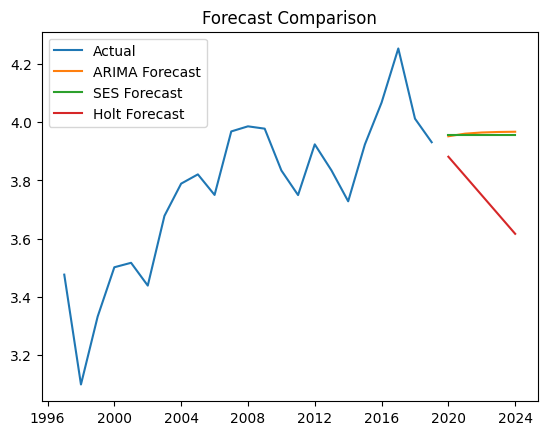

In [ ]:
plt.figure()
plt.plot(yield_ts, label="Actual")
plt.plot(forecast_arima, label="ARIMA Forecast")
plt.plot(ses_forecast, label="SES Forecast")
plt.plot(holt_forecast, label="Holt Forecast")
plt.legend()
plt.title("Forecast Comparison")
plt.show()


🧠
“Time series analysis was used to model historical crop yield data over multiple years. The ARIMA model captured temporal dependencies and long-term trends, enabling forecasting of future yield values. Stationarity was ensured using differencing, and model accuracy was evaluated using mean absolute error.”

🧠Milestone 3: Ethical and Scalability Analysis

Crop yield is also crucial for food security and economic planning. It determines the availability of food for the population and influences market prices and farmer income. Governments rely on yield data to plan food distribution, set minimum support prices, manage imports and exports, and design crop insurance schemes.

crop yield is commonly used in data analysis and machine learning models because it is a well-documented, numerical variable with long historical records. Its strong relationship with weather, soil, and farming inputs makes it an ideal target variable for time series analysis and predictive modeling aimed at improving agricultural decision-making.